In [14]:
!pip install ortools osmnx networkx folium matplotlib pandas numpy -q

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import folium
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

np.random.seed(42)

# Dark store location (Bengaluru - Koramangala)
DEPOT = (12.9352, 77.6245)

# Generate 50 random delivery locations around the depot
n_customers = 50
lats = DEPOT[0] + np.random.uniform(-0.03, 0.03, n_customers)
lons = DEPOT[1] + np.random.uniform(-0.03, 0.03, n_customers)

customers = pd.DataFrame({
    'customer_id': range(1, n_customers + 1),
    'lat': lats,
    'lon': lons,
    'demand': np.random.randint(1, 5, n_customers),
    'time_window_open': np.random.randint(0, 20, n_customers),
    'time_window_close': np.random.randint(25, 45, n_customers)
})

print(f"Total customers: {len(customers)}")
print(f"Total items to deliver: {customers['demand'].sum()}")
print(customers.head(10))

Total customers: 50
Total items to deliver: 128
   customer_id        lat        lon  demand  time_window_open  \
0            1  12.927672  77.652675       3                19   
1            2  12.962243  77.641008       4                12   
2            3  12.949120  77.650870       3                 8   
3            4  12.941120  77.648190       1                 2   
4            5  12.914561  77.630374       4                 6   
5            6  12.914560  77.649812       1                 5   
6            7  12.908685  77.599810       4                 7   
7            8  12.957171  77.606259       4                 8   
8            9  12.941267  77.597214       2                 4   
9           10  12.947684  77.614020       1                 0   

   time_window_close  
0                 30  
1                 40  
2                 27  
3                 44  
4                 28  
5                 43  
6                 27  
7                 43  
8                 

In [16]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Build distance matrix
all_lats = [DEPOT[0]] + list(customers['lat'])
all_lons = [DEPOT[1]] + list(customers['lon'])
n = len(all_lats)

distance_matrix = []
for i in range(n):
    row = []
    for j in range(n):
        dist = haversine(all_lats[i], all_lons[i], all_lats[j], all_lons[j])
        row.append(int(dist * 1000))
    distance_matrix.append(row)

# CVRP Solver
NUM_RIDERS = 8
RIDER_CAPACITY = 15

def solve_cvrp(distance_matrix, demands, num_riders, capacity):
    manager = pywrapcp.RoutingIndexManager(len(distance_matrix), num_riders, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        return distance_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        node = manager.IndexToNode(from_index)
        return demands[node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index, 0, [capacity] * num_riders, True, 'Capacity')

    search_params = pywrapcp.DefaultRoutingSearchParameters()
    search_params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
    search_params.time_limit.seconds = 15

    solution = routing.SolveWithParameters(search_params)
    return manager, routing, solution

demands = [0] + list(customers['demand'])
manager, routing, solution = solve_cvrp(distance_matrix, demands, NUM_RIDERS, RIDER_CAPACITY)

if solution is None:
    print("Retrying with relaxed constraints...")
    NUM_RIDERS = 10
    RIDER_CAPACITY = 20
    manager, routing, solution = solve_cvrp(distance_matrix, demands, NUM_RIDERS, RIDER_CAPACITY)

if solution is None:
    print("Still no solution — check data")
else:
    routes = []
    total_distance_cvrp = 0
    for rider in range(NUM_RIDERS):
        index = routing.Start(rider)
        route = []
        route_distance = 0
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route.append(node)
            next_index = solution.Value(routing.NextVar(index))
            route_distance += distance_matrix[manager.IndexToNode(index)][manager.IndexToNode(next_index)]
            index = next_index
        route.append(0)
        if len(route) > 2:
            routes.append({'rider': rider+1, 'route': route, 'distance_m': route_distance})
            total_distance_cvrp += route_distance

    print(f"\nCVRP Total distance: {total_distance_cvrp/1000:.2f} km")
    for r in routes:
        print(f"  Rider {r['rider']}: {len(r['route'])-2} stops, {r['distance_m']/1000:.2f} km")

Retrying with relaxed constraints...

CVRP Total distance: 62.29 km
  Rider 4: 9 stops, 10.76 km
  Rider 5: 5 stops, 7.27 km
  Rider 6: 7 stops, 9.55 km
  Rider 7: 7 stops, 8.72 km
  Rider 8: 8 stops, 7.96 km
  Rider 9: 9 stops, 9.83 km
  Rider 10: 5 stops, 8.20 km


Nearest Neighbour total distance: 49.55 km
CVRP total distance:              62.29 km
Improvement:                      -25.7%


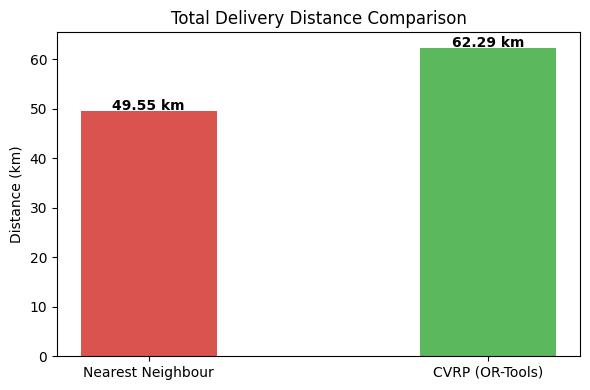

Distance comparison plot saved


In [17]:
def nearest_neighbour(distance_matrix, n_customers):
    unvisited = list(range(1, n_customers + 1))
    route = [0]
    total_dist = 0
    current = 0
    while unvisited:
        nearest = min(unvisited, key=lambda x: distance_matrix[current][x])
        total_dist += distance_matrix[current][nearest]
        route.append(nearest)
        current = nearest
        unvisited.remove(nearest)
    total_dist += distance_matrix[current][0]
    route.append(0)
    return route, total_dist

_, nn_distance = nearest_neighbour(distance_matrix, n_customers)

improvement = (nn_distance - total_distance_cvrp) / nn_distance * 100

print(f"Nearest Neighbour total distance: {nn_distance/1000:.2f} km")
print(f"CVRP total distance:              {total_distance_cvrp/1000:.2f} km")
print(f"Improvement:                      {improvement:.1f}%")

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Nearest Neighbour', 'CVRP (OR-Tools)'],
        [nn_distance/1000, total_distance_cvrp/1000],
        color=['#d9534f', '#5cb85c'], width=0.4)
plt.title('Total Delivery Distance Comparison')
plt.ylabel('Distance (km)')
for i, v in enumerate([nn_distance/1000, total_distance_cvrp/1000]):
    plt.text(i, v + 0.1, f'{v:.2f} km', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distance_comparison.png', dpi=150)
plt.show()
print("Distance comparison plot saved")

In [18]:
# Folium route map
m = folium.Map(location=DEPOT, zoom_start=14)

colors = ['red','blue','green','purple','orange','darkred','lightblue','darkgreen']

# Depot marker
folium.Marker(DEPOT, popup='Dark Store (Depot)',
              icon=folium.Icon(color='black', icon='home')).add_to(m)

# Plot each rider route
for r in routes:
    color = colors[r['rider'] % len(colors)]
    route_coords = []
    for node in r['route']:
        if node == 0:
            coords = DEPOT
        else:
            coords = (customers.iloc[node-1]['lat'], customers.iloc[node-1]['lon'])
        route_coords.append(coords)
        if node != 0:
            folium.CircleMarker(coords, radius=5, color=color,
                                fill=True, popup=f"Stop {node}").add_to(m)
    folium.PolyLine(route_coords, color=color, weight=2, opacity=0.7).add_to(m)

m.save('delivery_routes.html')
print("Route map saved as delivery_routes.html")

# SLA analysis
avg_stops_per_rider = np.mean([len(r['route'])-2 for r in routes])
avg_dist_per_rider  = np.mean([r['distance_m'] for r in routes]) / 1000
avg_time_per_rider  = avg_dist_per_rider / 20 * 60  # assume 20 km/h avg speed

print(f"\n── SLA Analysis ──")
print(f"Active riders:            {len(routes)}")
print(f"Avg stops per rider:      {avg_stops_per_rider:.1f}")
print(f"Avg distance per rider:   {avg_dist_per_rider:.2f} km")
print(f"Est. avg delivery time:   {avg_time_per_rider:.1f} min")
print(f"Distance improvement:     {improvement:.1f}% vs nearest-neighbour")

# Save outputs
customers.to_csv('customers.csv', index=False)
pd.DataFrame(routes).to_csv('routes.csv', index=False)
print("\nFiles saved: customers.csv, routes.csv, delivery_routes.html")

Route map saved as delivery_routes.html

── SLA Analysis ──
Active riders:            7
Avg stops per rider:      7.1
Avg distance per rider:   8.90 km
Est. avg delivery time:   26.7 min
Distance improvement:     -25.7% vs nearest-neighbour

Files saved: customers.csv, routes.csv, delivery_routes.html


NN avg distance per rider batch:   9.88 km
CVRP avg distance per rider:       8.90 km
Improvement:                       9.9%


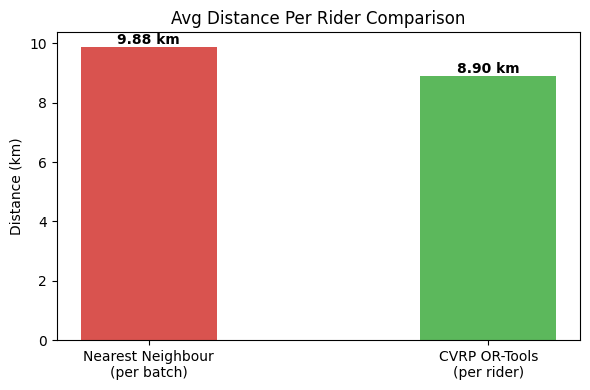

In [19]:
# Fair comparison: NN per-batch vs CVRP per-rider
# Split NN route into batches of same size as CVRP
avg_stops = int(avg_stops_per_rider)
nn_route, _ = nearest_neighbour(distance_matrix, n_customers)

# Split NN into rider-sized batches
nn_batches = []
stops = nn_route[1:-1]  # remove depot start/end
for i in range(0, len(stops), avg_stops):
    batch = [0] + stops[i:i+avg_stops] + [0]
    batch_dist = sum(distance_matrix[batch[j]][batch[j+1]] for j in range(len(batch)-1))
    nn_batches.append(batch_dist)

nn_avg_per_rider = np.mean(nn_batches) / 1000
cvrp_avg_per_rider = avg_dist_per_rider

improvement = (nn_avg_per_rider - cvrp_avg_per_rider) / nn_avg_per_rider * 100

print(f"NN avg distance per rider batch:   {nn_avg_per_rider:.2f} km")
print(f"CVRP avg distance per rider:       {cvrp_avg_per_rider:.2f} km")
print(f"Improvement:                       {improvement:.1f}%")

# Update bar chart
plt.figure(figsize=(6,4))
plt.bar(['Nearest Neighbour\n(per batch)', 'CVRP OR-Tools\n(per rider)'],
        [nn_avg_per_rider, cvrp_avg_per_rider],
        color=['#d9534f', '#5cb85c'], width=0.4)
plt.title('Avg Distance Per Rider Comparison')
plt.ylabel('Distance (km)')
for i, v in enumerate([nn_avg_per_rider, cvrp_avg_per_rider]):
    plt.text(i, v + 0.1, f'{v:.2f} km', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distance_comparison.png', dpi=150)
plt.show()